In [1]:
# uncomment if needed
# !pip install scikit-learn
# !pip install transformers
# !pip install matplotlib
# !pip install seaborn
# !pip install PySastrawi
# !pip install keras
# !pip install imblearn
# !pip install fasttext

In [2]:
import pandas as pd
import re

In [3]:
# --- Settings -------------------------------------------------------------
RAW_URL = "https://raw.githubusercontent.com/furaihan/proyek-data-mining/refs/heads/main/main.json"
TARGET_NAME = "data.json"        # final filename on disk
SAVE_TO_DRIVE = False            # set True to keep it in your Google Drive
DRIVE_FOLDER = "/content/drive/MyDrive/datasets"  # only used if SAVE_TO_DRIVE=True
# -------------------------------------------------------------------------

# 1️⃣  (Optional) Mount Google Drive
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    !mkdir -p "{DRIVE_FOLDER}"

# 2️⃣  Fetch the file and write it out
import requests, pathlib, time

def download_raw(url, outfile):
    t0 = time.time()
    r = requests.get(url, timeout=60)
    r.raise_for_status()               # 🔴 throws an error if 4xx/5xx
    pathlib.Path(outfile).write_bytes(r.content)
    print(f"✅ Saved {outfile}  ({len(r.content):,} bytes, {(time.time()-t0):.2f}s)")

out_path = f"{DRIVE_FOLDER}/{TARGET_NAME}" if SAVE_TO_DRIVE else TARGET_NAME
download_raw(RAW_URL, out_path)

# 3️⃣  Peek to confirm
!head -n 5 "{out_path}"


✅ Saved data.json  (2,335,062 bytes, 2.13s)


'head' is not recognized as an internal or external command,
operable program or batch file.


In [4]:
df = pd.read_json('data.json')
df.head()

,title,label,label_score
0,"Masuk Radar Pilwalkot Medan, Menantu Jokowi Be...",non-clickbait,0
1,Malaysia Sudutkan RI: Isu Kabut Asap hingga In...,non-clickbait,0
2,Viral! Driver Ojol di Bekasi Antar Pesanan Mak...,clickbait,1
3,"Kemensos Salurkan Rp 7,3 M bagi Korban Kerusuh...",non-clickbait,0
4,"Terkait Mayat Bayi Mengenaskan di Tangerang, S...",non-clickbait,0


In [5]:
df['label'].value_counts()

label
non-clickbait    8710
clickbait        6290
Name: count, dtype: int64

<Axes: ylabel='count'>

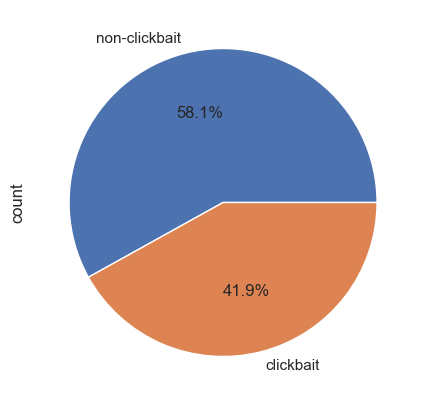

In [6]:
from matplotlib import pyplot as plt
import seaborn as sns

# pie plot with sns
plt.figure(figsize=(5, 5))
sns.set_theme()
df['label'].value_counts().plot.pie(autopct='%1.1f%%')

In [7]:
"""
import pandas as pd
from sklearn.utils import resample

# Separate the minority and majority classes
df_clickbait = df[df['label'] == 'clickbait']
df_non_clickbait = df[df['label'] == 'non-clickbait']

# Oversample the minority class
oversampled_clickbait = resample(df_clickbait,
                                 replace=True,    # Sample with replacement
                                 n_samples=len(df_non_clickbait), # Match the number of non-clickbait samples
                                 random_state=3006) # For reproducibility

# Combine the oversampled minority class with the majority class
balanced_df = pd.concat([df_non_clickbait, oversampled_clickbait], ignore_index=True)

# Check the class balance
print(balanced_df['label'].value_counts())
"""


"\nimport pandas as pd\nfrom sklearn.utils import resample\n\n# Separate the minority and majority classes\ndf_clickbait = df[df['label'] == 'clickbait']\ndf_non_clickbait = df[df['label'] == 'non-clickbait']\n\n# Oversample the minority class\noversampled_clickbait = resample(df_clickbait,\n                                 replace=True,    # Sample with replacement\n                                 n_samples=len(df_non_clickbait), # Match the number of non-clickbait samples\n                                 random_state=3006) # For reproducibility\n\n# Combine the oversampled minority class with the majority class\nbalanced_df = pd.concat([df_non_clickbait, oversampled_clickbait], ignore_index=True)\n\n# Check the class balance\nprint(balanced_df['label'].value_counts())\n"

In [8]:
# df = balanced_df

In [9]:
# df = df.sample(frac=1, random_state=2306).reset_index(drop=True)

<Axes: ylabel='count'>

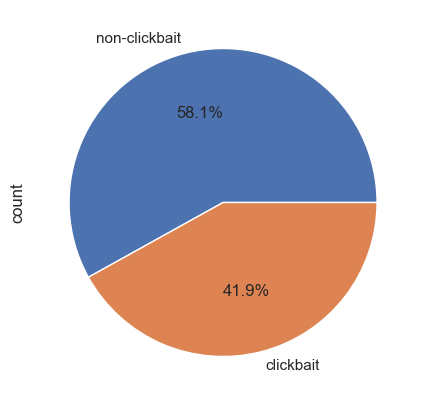

In [10]:
plt.figure(figsize=(5, 5))
sns.set_theme()
df['label'].value_counts().plot.pie(autopct='%1.1f%%')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   title        15000 non-null  object
 1   label        15000 non-null  object
 2   label_score  15000 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 351.7+ KB


In [12]:
df.isnull().sum()

title          0
label          0
label_score    0
dtype: int64

In [13]:
def clean_text(text):
    # Hapus karakter selain huruf, angka, tanda seru dan tanya
    text = re.sub(r'[^A-Za-z0-9?!]', ' ', text)
    text = re.sub(' +', ' ', text)     # Hapus spasi ganda
    return text.lower().strip()

In [16]:
# remove duplicates
df = df.drop_duplicates(subset=['title'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14970 entries, 0 to 14999
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   title        14970 non-null  object
 1   label        14970 non-null  object
 2   label_score  14970 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 467.8+ KB


In [20]:
df['cleaned_title'] = df['title'].apply(clean_text)

C:\Users\gerai\AppData\Local\Temp\ipykernel_19964\2887354604.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['cleaned_title'] = df['title'].apply(clean_text)


In [21]:
angka = ['nol', 'satu', 'dua', 'tiga', 'empat', 'lima', 'enam', 'tujuh', 'delapan', 'sembilan']
potential_clickbait_words = ['bikin', 'viral', 'gara', 'fakta', 'kejut']

def check_features(text):
    result = []
    # check if the text contains exclamation mark
    result.append(1 if '!' in text else 2)
    # check if the text contains question mark
    result.append(3 if '?' in text else 4)
    # check if the text contains multiple exclamation marks
    result.append(5 if '!!' in text else 6)
    # check if the text contains digit
    result.append(7 if any(char.isdigit() for char in text) else 8)
    # check if the text contains numbers
    result.append(9 if any(word.lower() in angka for word in text.split()) else 10)
    # check if the text contains potential clickbait words
    result.append(11 if any(word.lower() in potential_clickbait_words for word in text.split()) else 12)
    return result

df['features'] = df['title'].apply(check_features)

C:\Users\gerai\AppData\Local\Temp\ipykernel_19964\1909701984.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['features'] = df['title'].apply(check_features)


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14970 entries, 0 to 14999
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   title          14970 non-null  object
 1   label          14970 non-null  object
 2   label_score    14970 non-null  int64 
 3   features       14970 non-null  object
 4   cleaned_title  14970 non-null  object
dtypes: int64(1), object(4)
memory usage: 701.7+ KB


In [23]:
df.head(5)

,title,label,label_score,features,cleaned_title
0,"Masuk Radar Pilwalkot Medan, Menantu Jokowi Be...",non-clickbait,0,"[2, 4, 6, 8, 10, 12]",masuk radar pilwalkot medan menantu jokowi ber...
1,Malaysia Sudutkan RI: Isu Kabut Asap hingga In...,non-clickbait,0,"[2, 4, 6, 8, 10, 12]",malaysia sudutkan ri isu kabut asap hingga inv...
2,Viral! Driver Ojol di Bekasi Antar Pesanan Mak...,clickbait,1,"[1, 4, 6, 8, 10, 12]",viral! driver ojol di bekasi antar pesanan mak...
3,"Kemensos Salurkan Rp 7,3 M bagi Korban Kerusuh...",non-clickbait,0,"[2, 4, 6, 7, 10, 12]",kemensos salurkan rp 7 3 m bagi korban kerusuh...
4,"Terkait Mayat Bayi Mengenaskan di Tangerang, S...",non-clickbait,0,"[2, 4, 6, 8, 10, 12]",terkait mayat bayi mengenaskan di tangerang se...


In [25]:
df['cleaned_title'].to_csv("judul_only.txt", index=False, header=False)

In [26]:
import fasttext

# Latih FastText unsupervised (skipgram, bisa juga cbow)
model = fasttext.train_unsupervised('judul_only.txt', model='skipgram', dim=100)  # bisa dim=50 atau 100
model.save_model("fasttext_clickbait.bin")


In [28]:
df['fasttext_vector'] = df['cleaned_title'].apply(lambda x: model.get_word_vector(' '.join(x)))

C:\Users\gerai\AppData\Local\Temp\ipykernel_19964\1707461026.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['fasttext_vector'] = df['cleaned_title'].apply(lambda x: model.get_word_vector(' '.join(x)))


In [29]:
df.head(5)

,title,label,label_score,features,cleaned_title,fasttext_vector
0,"Masuk Radar Pilwalkot Medan, Menantu Jokowi Be...",non-clickbait,0,"[2, 4, 6, 8, 10, 12]",masuk radar pilwalkot medan menantu jokowi ber...,"[-0.0033904295, 0.0036065064, -0.00085008156, ..."
1,Malaysia Sudutkan RI: Isu Kabut Asap hingga In...,non-clickbait,0,"[2, 4, 6, 8, 10, 12]",malaysia sudutkan ri isu kabut asap hingga inv...,"[-0.007862845, 0.0065753767, -0.0025084084, -0..."
2,Viral! Driver Ojol di Bekasi Antar Pesanan Mak...,clickbait,1,"[1, 4, 6, 8, 10, 12]",viral! driver ojol di bekasi antar pesanan mak...,"[-0.0029843764, 0.0025419523, -0.0008353943, -..."
3,"Kemensos Salurkan Rp 7,3 M bagi Korban Kerusuh...",non-clickbait,0,"[2, 4, 6, 7, 10, 12]",kemensos salurkan rp 7 3 m bagi korban kerusuh...,"[-0.0050060945, 0.0032503917, -0.0014461646, -..."
4,"Terkait Mayat Bayi Mengenaskan di Tangerang, S...",non-clickbait,0,"[2, 4, 6, 8, 10, 12]",terkait mayat bayi mengenaskan di tangerang se...,"[-0.0017554347, 0.0018917714, -0.0010984358, -..."


In [46]:
# feature engineering value documentation
feature_engineering_value = {
    'exclamation_mark': "1 if '!' in text else 2",
    'question_mark': "3 if '?' in text else 4",
    'multiple_exclamation_mark': "5 if '!!' in text else 6",
    'digit': "7 if any(char.isdigit() for char in text) else 8",
    'numbers': "9 if any(word.lower() in angka for word in text.split()) else 10",
    'potential_clickbait_words': "11 if any(word.lower() in potential_clickbait_words for word in text.split()) else 12"
}

In [47]:
# steps feature engineering

def step_by_step_feature_engineering(text):
    steps = []

    # Step 1: Data Asli
    steps.append(("Data Asli", text))

    # Step 2: Cek tanda seru
    step2 = 1 if '!' in text else 2
    steps.append(("Cek Tanda Seru", step2))

    # Step 3: Cek tanda tanya
    step3 = 3 if '?' in text else 4
    steps.append(("Cek Tanda Tanya", step3))

    # Step 4: Cek beberapa tanda seru
    step4 = 5 if '!!' in text else 6
    steps.append(("Cek Beberapa Tanda Seru", step4))

    # Step 5: Cek digit
    step5 = 7 if any(char.isdigit() for char in text) else 8
    steps.append(("Cek Digit", step5))

    # Step 6: Cek angka dalam teks
    step6 = 9 if any(word.lower() in angka for word in text.split()) else 10
    steps.append(("Cek Angka dalam Teks", step6))

    # Step 7: Cek kata clickbait potensial
    step7 = 11 if any(word.lower() in potential_clickbait_words for word in text.split()) else 12
    steps.append(("Cek Kata Clickbait Potensial", step7))

    return pd.DataFrame(steps, columns=["Langkah", "Contoh Data"])

In [ ]:
import numpy as np
X_fasttext = df['fasttext_vector'].tolist()
X_features = df['features'].tolist()
X = np.hstack([X_fasttext, X_features])
y = df['label_score']

In [31]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import GradientBoostingClassifier
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=2025)

clf = GradientBoostingClassifier(validation_fraction=0.1,
                                tol=0.0001,
                                subsample=0.7,
                                n_iter_no_change=10,
                                n_estimators=np.int64(800),
                                min_samples_leaf=5,
                                max_features=0.5,
                                max_depth=5,
                                learning_rate=0.05,
                                ccp_alpha=0.0)

pipe = Pipeline([
    ("oversample", ros),   # ↳ only applied to the *training* fold
    ("model", clf),        #    never touches the validation fold
])

In [ ]:
# Best parameters found:  {'model__validation_fraction': 0.1, 'model__tol': 0.0001, 'model__subsample': 0.7, 'model__n_iter_no_change': 10, 'model__n_estimators': np.int64(800), 'model__min_samples_leaf': 5, 'model__max_features': 0.5, 'model__max_depth': 5, 'model__learning_rate': 0.05, 'model__ccp_alpha': 0.0}

In [33]:
import numpy as np

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1453)
accuracy = cross_val_score(pipe, X_fasttext, y, cv=cv, scoring="accuracy", n_jobs=-1)
print("Accuracy per fold :", np.round(accuracy, 4))
print("Mean accuracy      :", accuracy.mean())

Accuracy per fold : [0.6533 0.6379 0.6316 0.6229 0.6283]
Mean accuracy      : 0.6348029392117569


In [54]:
pipe.fit(X, y)

Pipeline(steps=[('oversample', RandomOverSampler(random_state=2025)),
                ('model',
                 GradientBoostingClassifier(max_depth=15, max_features='sqrt',
                                            n_estimators=200,
                                            random_state=1453))])

In [55]:
import joblib
joblib.dump(pipe, "gradient_boosting_ros.pkl")

['gradient_boosting_ros.pkl']